# 01 – Data exploration
Goal: understand the London Inside Airbnb listings data before building a model to predict nightly price.

In [1]:
    import pandas as pd

    df = pd.read_csv("../data/raw/listings.csv.gz")
    print(df.shape)
    print(df.columns.tolist())



(92638, 90)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 

In [2]:
print(df["neighbourhood_cleansed"].nunique(), "neighbourhoods")
print(df[["latitude", "longitude"]].mean().round(2))
df["neighbourhood_cleansed"].value_counts().head()

33 neighbourhoods
latitude     51.51
longitude    -0.13
dtype: float64


neighbourhood_cleansed
Westminster               10876
Tower Hamlets              6842
Camden                     6199
Kensington and Chelsea     6184
Hackney                    5756
Name: count, dtype: int64

In [3]:
print("Data type:", df["price"].dtype)
print("Missing prices:", df["price"].isna().sum())
df["price"].head(10)

Data type: str
Missing prices: 30398


0    $234.50
1    $127.00
2    $137.50
3    $606.67
4     $68.30
5     $49.06
6        NaN
7        NaN
8        NaN
9    $268.33
Name: price, dtype: str

In [4]:
df["price_num"] = (
    df["price"]
    .str.replace(r"[£$,]", "", regex=True)
    .astype(float)
)
df["price_num"].describe().round(1)

count     62240.0
mean        271.5
std        2190.6
min           2.2
25%         100.0
50%         180.0
75%         300.0
max      527524.0
Name: price_num, dtype: float64

In [5]:
key_cols = [
    "price", "neighbourhood_cleansed", "room_type", "accommodates",
    "bedrooms", "bathrooms", "beds", "latitude", "longitude",
    "number_of_reviews", "review_scores_rating",
]
df[key_cols].isna().mean().sort_values(ascending=False).round(3)

bathrooms                 0.376
beds                      0.351
price                     0.328
bedrooms                  0.259
review_scores_rating      0.237
neighbourhood_cleansed    0.000
room_type                 0.000
accommodates              0.000
latitude                  0.000
longitude                 0.000
number_of_reviews         0.000
dtype: float64

In [6]:
df = df.dropna(subset=["price_num"]).copy()
print(df.shape)

(62240, 91)


In [7]:
df["price_num"].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999]).round(1)

0.001      14.2
0.010      35.0
0.050      50.7
0.950     676.0
0.990    1373.5
0.999    6234.1
Name: price_num, dtype: float64

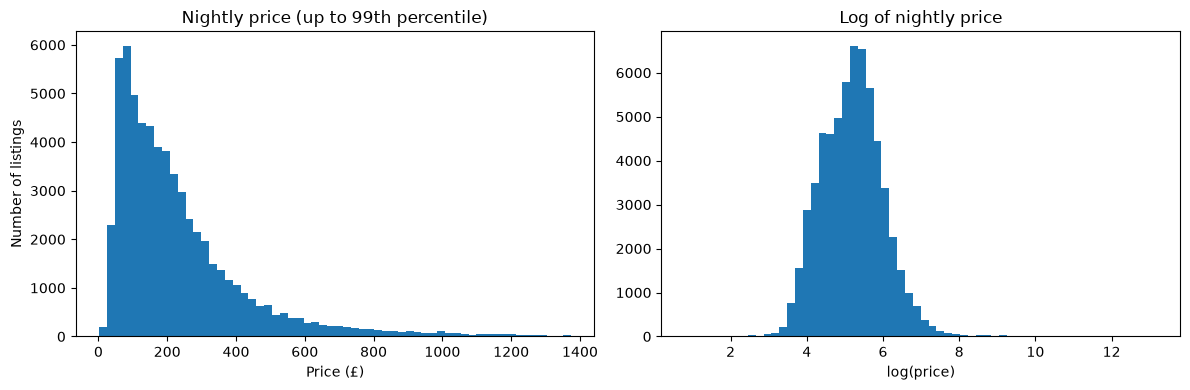

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

cap = df["price_num"].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df["price_num"] <= cap, "price_num"], bins=60)
axes[0].set_title("Nightly price (up to 99th percentile)")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of listings")

axes[1].hist(np.log(df["price_num"]), bins=60)
axes[1].set_title("Log of nightly price")
axes[1].set_xlabel("log(price)")

plt.tight_layout()
plt.savefig("../reports/figures/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
pd.crosstab(
    df["review_scores_rating"].isna(),
    df["number_of_reviews"] == 0,
    rownames=["review score missing"],
    colnames=["zero reviews"],
)

zero reviews,False,True
review score missing,,
False,48670,0
True,0,13570


In [10]:
before = len(df)
df = df[(df["price_num"] >= 20) & (df["price_num"] <= 1000)].copy()
print(f"Removed {before - len(df)} listings; {len(df)} remain.")

Removed 1388 listings; 60852 remain.


In [11]:
df.groupby("room_type")["price_num"].agg(["count", "median"]).round(0)

,count,median
room_type,,
Entire home/apt,40885,235.0
Hotel room,108,156.0
Private room,19686,82.0
Shared room,173,46.0


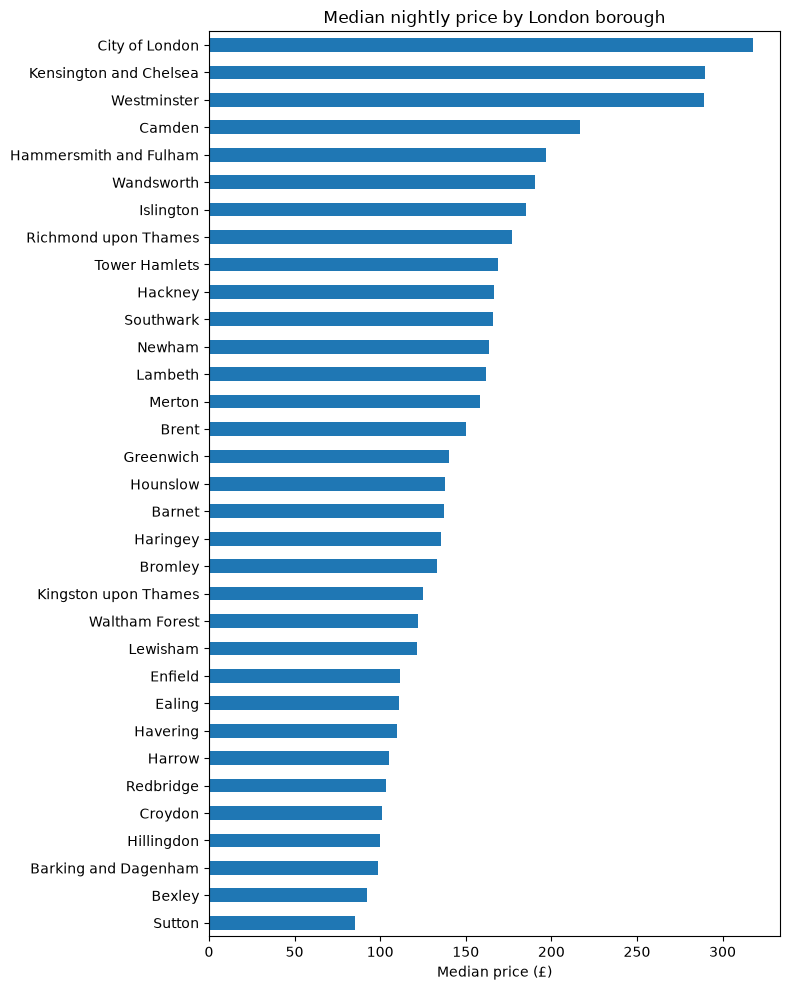

In [12]:
borough_medians = (
    df.groupby("neighbourhood_cleansed")["price_num"]
    .median()
    .sort_values()
)

plt.figure(figsize=(8, 10))
borough_medians.plot(kind="barh")
plt.title("Median nightly price by London borough")
plt.xlabel("Median price (£)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/figures/price_by_borough.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
df.groupby("accommodates")["price_num"].agg(["count", "median"]).round(0)

,count,median
accommodates,,
1,6457,67.0
2,22461,119.0
3,4851,169.0
4,12659,237.0
5,3823,262.0
6,5820,326.0
7,1337,337.0
8,1900,386.0
9,420,350.0


- Prices outside £20–£1,000 (about 2% of listings) were removed as likely errors or a separate luxury market.
- Price is right-skewed; log(price) is roughly bell-shaped, so the model will predict log(price).
- All listings with missing review scores have zero reviews, so this will become a "has reviews" feature rather than being filled in.

## Initial findings
- The dataset contains 92,638 London listings. 30,398 (about 33%) have no price, likely because they were not open for booking when the data was collected. They are removed, as the model needs a known price to learn from, leaving 62,240 listings.
- Prices are heavily right-skewed: median £180, mean £272, with a maximum of £527,524 a night (clearly an error).
- Prices outside £20–£1,000 were removed as likely errors or a separate luxury market. This removed 1,388 listings (about 2%), leaving 60,852.
- log(price) is roughly bell-shaped, so the model will predict log(price) rather than price.
- All 13,570 listings with a missing review score have zero reviews, so this will become a "has reviews" feature rather than being filled in.
- Bathrooms (38%), beds (35%) and bedrooms (26%) have missing values in the full dataset, to be filled in during cleaning.
- Room type strongly affects price: entire homes have a median of £235, private rooms £82 and shared rooms £46.
- Location matters: central boroughs (City of London, Kensington and Chelsea, Westminster) are the most expensive, while outer boroughs such as Sutton and Bexley are the cheapest.
- Price rises with the number of guests, from a median of £67 for one guest to £237 for four and £386 for eight. Above about ten guests there are few listings, so prices there are less reliable.